# Playground

Helpful links on training troubleshooting:
- [underfitting](https://stats.stackexchange.com/questions/352036/what-should-i-do-when-my-neural-network-doesnt-learn)
- [Unit testing ML](https://thenerdstation.medium.com/how-to-unit-test-machine-learning-code-57cf6fd81765)

In [1]:
import os
import sys
from pathlib import Path
import time
import json
import numpy as np
import diffusers
import xarray as xr
sys.path.append(os.path.abspath("../diffusionsim"))
import torch
import torch.nn as nn
from dataclasses import dataclass, asdict, field
import matplotlib.pyplot as plt
from pprint import pprint
# device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [2]:
import diffusionsim.training_utils as tru
import diffusionsim.trainers as trainers
import diffusionsim.mydatasets as data
import diffusionsim.evaluations as evals
import diffusionsim as diff

# Debugging Training Classes

In [3]:
from abc import ABC, abstractmethod
from collections import defaultdict
import copy
import dataclasses

In [4]:
REF_BATCH_SIZE = 128
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
#exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
in_notebook = True
dataset_type="climsim"

## Diffusion Training

In [5]:
def setup_diffusion_run(
    num_models, exp_id, base_run_id, 
    data_vars, 
    image_dim,
    batch_size=128, 
    shuffle_indices=False, 
    use_tendencies=False, source='local-vzarr'
):
    dconfig = tru.my_dconfig(source, data_vars, in_notebook, shuffle_indices, dataset_type, batch_size, use_tendencies)
    dconfig.train_test_split = [0.001]
    tconfigs, mconfigs = [], []
    dconfig.batch_checkpoint_interval = 32
    dconfig.batch_logging_interval = 128
    learning_rates = [1e-5, 1e-5, 1e-5, 1e-5]
    unet_layers_per_block = [1, 1, 2, 2, 1]
    block_out_channels = [
        (32, 32, 64),
        (16, 32, 48),
        (16, 32, 64),
        (32, 48, 64),
    ]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.lr_scheduler = "cosine"
        tconfig.lr_warmup_steps = 200
        tconfig.max_T_sample = 51
        tconfig.clip_gradients = True

        unet = tru.UNetParams()
        if image_dim == 1:
            unet.block_out_channels = block_out_channels[i] #if data_vars == "v1" else None
            unet.down_block_types = ("DownResnetBlock1D", "AttnDownBlock1D", "DownBlock1D") #if data_vars=="v1" else None
            unet.up_block_types = ("UpResnetBlock1D", "AttnUpBlock1D", "UpBlock1D") #if data_vars=="v1" else None
            unet.in_channels = 10 if data_vars == "v1" else 14
        else:
            unet.block_out_channels = (128, 256, 512) if data_vars == "v1" else (256, 512, 1024)
            unet.down_block_types = ("DownBlock2D", "DownBlock2D", "DownBlock2D")
            unet.up_block_types = ("UpBlock2D", "UpBlock2D", "UpBlock2D")
            unet.in_channels = 128 if data_vars == "v1" else 368
        unet.out_channels = unet.in_channels
        unet.layers_per_block = 1
        unet.norm_num_groups = 4

        scheduler = tru.SchedulerParams()
        scheduler.beta_schedule = "linear"
        scheduler.clip_sample = False
        scheduler.clip_sample_range = 4.0
        scheduler.beta_end = 0.02

        mconfig = tru.ModelConfig(unet=unet, scheduler=scheduler)
        mconfig.model_type = 'ddpm_diffusion1d'
        mconfig.data_vars = data_vars

        tconfigs.append(tconfig)
        mconfigs.append(mconfig)
    return(tconfigs, mconfigs, dconfig)

In [5]:
trainer = None
NUM_MODELS = 4
num_epochs = 15
REF_BATCH_SIZE = 128
dataset_type = "climsim_diffusion1d"
image_dim = 1
data_vars = 'v2'
in_notebook = True

exp_id = "diffusion_hp_search"
base_dir = os.path.join(exp_dir, exp_id)
run_id = "diff_1d_v2"

tconfigs, mconfigs, dconfig = setup_diffusion_run(
    NUM_MODELS, exp_id, run_id, data_vars, image_dim, batch_size=16, shuffle_indices=True, use_tendencies=True
)

dconfig.phases = ['train']

NameError: name 'setup_diffusion_run' is not defined

In [15]:
dataloaders, indices = tru.load_dataloaders(dconfig, log=True)

In [16]:
bind = dataloaders[0].dataset.ygen._batch_selectors.selectors
len(bind)

13

In [17]:
import diffusers
from diffusers.models import UNet1DModel

In [19]:
from dataclasses import dataclass, field, asdict
from typing import Tuple, Dict
import torch
@dataclass
class UNetParams:
    sample_size: Tuple[int, int] = field(default_factory=lambda: (16, 24))
    in_channels: int = 128
    out_channels: int = 128
    extra_in_channels: int = 0
    block_out_channels: Tuple = field(default_factory=lambda: (32, 64, 64, 128))  # num output channel for each UNet block
    down_block_types: Tuple = field(default_factory=lambda: (
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "DownBlock2D",
    ))
    up_block_types: Tuple = field(default_factory=lambda: (
        "UpBlock2D",  # a regular ResNet upsampling block
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",
    ))
    layers_per_block: int = 1
    norm_num_groups: int = 2
    act_fn: str = "silu" # https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/activations.py#L27
    freq_shift: float = 0.0 # fourier freq shift
    use_timestep_embedding: bool = True
    time_embedding_dim: int = 32

In [ ]:
params = UNetParams()
model = UNet1DModel(**dataclasses.asdict(params)).to("cuda")

TypeError: UNet1DModel.__init__() got an unexpected keyword argument 'time_embedding_dim'

In [ ]:
x = sample = torch.randn(4, 10,  64).to("cuda")
t = torch.tensor([5, 5, 5, 5], dtype=torch.long, device=x.device)

In [ ]:

    @register_to_config
    def __init__(
        self,
        sample_size: int = 65536,
        sample_rate: Optional[int] = None,
        in_channels: int = 2,
        out_channels: int = 2,
        extra_in_channels: int = 0,
        time_embedding_type: str = "fourier",
        time_embedding_dim: int = 0,
        flip_sin_to_cos: bool = True,
        use_timestep_embedding: bool = False,
        freq_shift: float = 0.0,
        down_block_types: Tuple[str] = ("DownBlock1DNoSkip", "DownBlock1D", "AttnDownBlock1D"),
        up_block_types: Tuple[str] = ("AttnUpBlock1D", "UpBlock1D", "UpBlock1DNoSkip"),
        mid_block_type: Tuple[str] = "UNetMidBlock1D",
        out_block_type: str = None,
        block_out_channels: Tuple[int] = (32, 32, 64),
        act_fn: str = None,
        norm_num_groups: int = 8,
        layers_per_block: int = 1,
        downsample_each_block: bool = False,
    ):
        super().__init__()
        self.sample_size = sample_size

        # time
        if time_embedding_type == "fourier":
            time_embed_dim = time_embedding_dim or block_out_channels[0] * 2
            if time_embed_dim % 2 != 0:
                raise ValueError(f"`time_embed_dim` should be divisible by 2, but is {time_embed_dim}.")
            self.time_proj = GaussianFourierProjection(
                embedding_size=time_embed_dim // 2, set_W_to_weight=False, log=False, flip_sin_to_cos=flip_sin_to_cos
            )
            timestep_input_dim = time_embed_dim
        elif time_embedding_type == "positional":
            time_embed_dim = time_embedding_dim or block_out_channels[0] * 4
            self.time_proj = Timesteps(
                block_out_channels[0], flip_sin_to_cos=flip_sin_to_cos, downscale_freq_shift=freq_shift
            )
            timestep_input_dim = block_out_channels[0]
        else:
            raise ValueError(
                f"{time_embedding_type} does not exist. Please make sure to use one of `fourier` or `positional`."
            )

In [ ]:
temb = model.time_proj(t)
temb.shape

torch.Size([4, 256])

In [ ]:
timestep_embed = temb[..., None]
timestep_embed = timestep_embed.repeat([1, 1, sample.shape[2]]).to(sample.dtype)
timestep_embed = timestep_embed.broadcast_to((sample.shape[:1] + timestep_embed.shape[1:]))

In [ ]:
timestep_embed.shape

torch.Size([4, 32, 64])

In [ ]:
model.time_proj.weight.shape
temb = model.time_proj(t)
temb.shape

torch.Size([1, 256])

In [ ]:
model.time_mlp(temb).shape

torch.Size([4, 32])

In [ ]:
model.time_mlp

TimestepEmbedding(
  (linear_1): Linear(in_features=32, out_features=256, bias=True)
  (act): SiLU()
  (linear_2): Linear(in_features=256, out_features=32, bias=True)
)

### Cleaning legacy dataclass formats

In [ ]:
pkeys = "num_epochs phases distributed_training batch_logging_interval batch_checkpoint_interval log_gradients".split()
delete = True
import inspect
for key in pkeys:
    for run_id in run.run_ids:
        tconfig = run.logs[run_id]['training_config']
        if key in tconfig:
            print(key, tconfig[key])
            if delete and key in inspect.signature(tru.DataConfig).parameters:
                run.logs['data_config'][key] = copy.deepcopy(tconfig[key])
                del tconfig[key]
        else:
            print(key, "not found")
            break

NameError: name 'run' is not defined

In [ ]:
rids = run.run_ids
for r in rids:
    tcon = run.logs[r]['training_config']
    run.logs['data_config']['checkpoint_best_epoch'] = tcon['save_best_epoch']
    del tcon['save_best_epoch']

NameError: name 'run' is not defined

## Train Clim

In [8]:
def setup_climsim_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128, use_tendencies=True, shuffle_indices=False):
    dataset_type = "climsim"
    #dconfig = tru.my_dconfig("local_vzarr", "v1", in_notebook, False, "climsim")
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, shuffle_indices,
                                dataset_type, batch_size, use_tendencies,
                             )
    dconfig.train_test_split = [0.001, 0.001]
    dconfig.checkpoint_every_epoch = True
    dconfig.phases = ['train', 'eval']
    dconfig.log_gradients = True
    tconfigs, mconfigs = [], []

    learning_rates = [1e-3] * num_models
    distloss_weights = [0.0] * num_models
    diffloss_weights = [0.0, 10.0, 10.0]
    diff_start_epochs = [0,0,0] # [11, 1, 1]

    image_dim = 1
    target_variables_distloss = [68, 73, 82] # previously included 60 asw
    num_gaussians = [3, 2, 3]
    run_ids = ["mse-only", "decode-only", "encode-decode"]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=run_ids[i])
        tconfig.learning_rate_params.update(dict(
            learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE,
            lr_scheduler="steplr",
            step_size=1,
            gamma=0.85,
            min_lr=1e-6,
        ))

        loss_weights = {'mse': 1.0, 'distribution': distloss_weights[i], 'diffusion': diffloss_weights[i]}
        loss_schedule = {'mse': [0,100], 'distribution': [0,100], 'diffusion': [diff_start_epochs[i],100]}
        tconfig.loss_weight_params.update(dict(
            loss_weights=loss_weights,
            loss_schedule=loss_schedule,
            alpha=0.5, 
            strategy="gradnorm",
            update_interval=20,
        ))

        tconfig.clip_gradients = True
        tconfig.distloss_var_inds = target_variables_distloss
        tconfig.num_gaussians = num_gaussians[:len(target_variables_distloss)]
        
        tconfig.diffusion_loss_noise_level = 10
        tconfig.diffusion_strategy = "1d-decode-only" if i<2 else "1d-encode-decode"
        #tconfig.diffusion_image_loss = "1d-mse"
        tconfigs.append(tconfig)
        
        mconfig = tru.ModelConfig(scheduler=tru.SchedulerParams(
            prediction_type="epsilon",
            beta_schedule="linear",
        ))
        mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)



In [9]:
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "DiffLossTesting"
run_id = "decode-only-test"
num_models = 3
base_dir = os.path.join(exp_dir, exp_id)

In [10]:
run = evals.Run(exp_id, "decode-only", climsim_run = True)

In [11]:
run.logs['decode-only']['losses'].keys()

dict_keys(['train', 'eval'])

In [12]:
tconfigs, mconfigs, dconfig = setup_climsim_run(
    num_models, exp_id, run_id, data_vars='v1', batch_size=64, use_tendencies=True
)

In [13]:
pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           num_epochs=10,
           phases=['train', 'eval'],
           train_test_split=[0.001, 0.001],
           dataloader_params=DataLoaderParams(batch_size=64,
                                              shuffle=True,
                                              num_workers=0,
                                              prefetch_factor=None,
                                              persistent_workers=False,
                                              multiprocessing_context=None,
                                              pin_memory=False),
           data_vars='v1',
           use_tendencies=True,
           norm_info='image',
           chunksize={},
           shuffle_indices=False,
           distributed_training=False,
           checkpoint_best_epoch=True,
    

In [14]:
dataloaders, indices = tru.load_dataloaders(dconfig, log=True)
ds = dataloaders[0].dataset
dutils = ds.dutils

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [15]:
unet = tru.load_diffusion_model(model_id='diff_1d_v1')
scheduler = tru.load_scheduler(mconfigs[0])

In [16]:
unet.config.down_block_types

['DownResnetBlock1D', 'AttnDownBlock1D', 'DownBlock1D']

In [19]:

AbstractTrainer = trainers.AbstractTrainer
diffusion_loss = trainers.diffusion_loss
distribution_loss = trainers.distribution_loss
register_incident = trainers.register_incident


In [20]:

class ClimsimTrainer(AbstractTrainer):
    def __init__(self, dataloaders, indices, mconfigs, tconfigs, base_dir, base_run_id, **kwargs):
        super().__init__(dataloaders, indices, mconfigs, tconfigs, base_dir, base_run_id)
        self.tracked_losses = ["mse"]
        self.track_loss_weights = False
        for run_id in self.run_ids:
            lw_params = self.training_configs[run_id].loss_weight_params #@['weights']
            
            for ltype in ["distribution", "diffusion"]:
                if(lw_params['loss_weights'][ltype] > 0 and ltype not in self.tracked_losses):
                    self.tracked_losses.append(ltype)
            
            if(lw_params['strategy'] == "gradnorm"):
                self.track_loss_weights = True
                self.gradnorm_loss_fn = torch.nn.L1Loss(reduction='sum')

        if ("diffusion" in self.tracked_losses):
            assert 'unet' in kwargs, "unet must be provided for diffusion loss"
            self.unet = kwargs['unet'].to(self.device)
            scheds = [kwargs['scheduler'] for _ in range(len(self.run_ids))] if 'scheduler' in kwargs else [tru.load_scheduler(mconfig) for mconfig in self.mconfigs.values()]
            self.schedulers = dict(zip(self.run_ids, scheds))
        #if ("distribution" in self.tracked_losses):
        
    def _make_image(self, y, image_dim=1):
        if not torch.is_tensor(y):
            y = torch.tensor(y)
        ds = self.dataloaders['train'].dataset
        # desired output is (BS, C, H, W)
        return(tru.imagify(y, ds.dutils, 'y', image_dim))

    def setup_training(self, num_epochs, log=True, save_indices=False):
        super().setup_training(num_epochs, log, save_indices)
        self.loss_weights, self.lw_optimizers, self.lw_history, self.L0 = {}, {}, defaultdict(list), defaultdict(dict)
        for run_id in self.run_ids:
            params = self.training_configs[run_id].loss_weight_params
            lws = [params['loss_weights'][k] for k in self.tracked_losses]
            if self.track_loss_weights:
                lws = torch.tensor(lws, device=self.device, dtype=torch.float32).mul_(params['T'] / sum(lws))
                self.loss_weights[run_id] = lws.requires_grad_(True)
                self.lw_optimizers[run_id] = torch.optim.SGD([self.loss_weights[run_id]], lr=self.training_configs[run_id].loss_weight_params['lr'])
                self.lw_history[run_id].append(lws.detach().cpu().numpy().tolist())
            else: 
                self.loss_weights[run_id] = torch.tensor(lws, device=self.device, requires_grad=False, dtype=torch.float32) / sum(lws)
    
    def _return_loss_weights(self, run_id, batch_losses=None):
        lw_params = self.training_configs[run_id].loss_weight_params
        loss_weight = self.loss_weights[run_id].detach().clone()
        for i, loss_type in enumerate(self.tracked_losses):
            loss_sched = lw_params['loss_schedule'][loss_type]
            if (isinstance(loss_sched, int) and self.current_epoch < loss_sched):
                loss_weight[i] = 0
            elif isinstance(loss_sched, list) and not (loss_sched[0] <= self.current_epoch < loss_sched[1]):
                loss_weight[i] = 0
        return(loss_weight)
            
    def apply_loss(self, y_hat, batch, batch_losses, run_id, step):
        #model, optimizer, tconfig = self.models[run_id], self.optimizers[run_id], self.training_configs[run_id]
        x, y = batch[0].to(self.device), batch[1].to(self.device)
        self.models[run_id].zero_grad()
        VAR_IND = None
        for loss_type in self.tracked_losses:
            if(loss_type == "mse"):
                loss = self.loss_fn(y_hat, y)
            elif(loss_type == "distribution"):
                loss, VAR_IND = distribution_loss(self, y_hat, y, run_id, step)
                batch_losses[run_id]['VAR_IND'] = VAR_IND
            elif(loss_type == "diffusion"):
                loss = diffusion_loss(self, y_hat, run_id)
            else:
                raise ValueError(f"Invalid loss type: {loss_type}")
            if(self.current_phase == 'train' and self._gradients_ops(run_id, loss_type, loss, step)):
                self.nan_incidents[run_id][-1]['inputs'] = batch
                loss = torch.tensor(0)
            batch_losses[run_id][loss_type] = loss
        losses = torch.stack([batch_losses[run_id][l] for l in self.tracked_losses]).float()
        if(self.track_loss_weights and 'l0' not in self.L0[run_id]):
            self.L0[run_id]['l0'] = torch.clamp(losses.detach().clone(), max=200)
        if (self.track_loss_weights and VAR_IND is not None):
            if (self.L0[run_id].get(VAR_IND, 200) >= 150 and batch_losses[run_id]['distribution'] < 150):
                self.L0[run_id][VAR_IND] = batch_losses[run_id]['distribution'].detach().clone()
        return(losses)

    def _update_gradnorm_weights(self, run_id, batch_losses):
        params = self.training_configs[run_id].loss_weight_params
        W = self.loss_weights[run_id]
        assert W.requires_grad, "loss weights must require grad"
        param, grads = self.models[run_id].get_param(params['gradnorm_layer']), []
        for i, loss_type in enumerate(self.tracked_losses):
            grad = torch.autograd.grad(W[i] * batch_losses[loss_type], param, retain_graph=True, create_graph=True)[0]
            grads.append(torch.norm(grad))
        grads = torch.stack(grads)
        losses = torch.stack([batch_losses[l] for l in self.tracked_losses]).detach()
        l0 = self.L0[run_id]['l0']
        if "VAR_IND" in batch_losses and batch_losses['VAR_IND'] in self.L0[run_id]:
            i = self.tracked_losses.index("distribution")
            l0[i] = self.L0[run_id][batch_losses['VAR_IND']]
        loss_ratio = losses / l0
        target_grads = grads.detach().mean() * (loss_ratio / loss_ratio.mean()) ** params['alpha']
        gradnorm_loss = self.gradnorm_loss_fn(grads, target_grads)
        w_grad = torch.autograd.grad(gradnorm_loss, W, retain_graph=False)[0]
        with torch.no_grad():
            W = W - params['lr'] * w_grad
            if (W < 0).any():
                W = torch.clamp(torch.exp(W), min=1e-3)
            self.loss_weights[run_id] = (params['T'] * W/W.sum()).detach().requires_grad_(True)

    def _run_batch(self, batch, step):
        print(f"Running batch {step}")
        x, y = batch[0].to(self.device), batch[1].to(self.device)
        batch_losses = {}
        for run_id in self.run_ids:
            lw_params = self.training_configs[run_id].loss_weight_params
            batch_losses[run_id] = {}
            y_hat = self.models[run_id](x) 
            losses = self.apply_loss(y_hat, batch, batch_losses, run_id, step)
            if self.current_phase == 'train':
                loss_weights = self._return_loss_weights(run_id, batch_losses[run_id])
                if(lw_params['strategy'] == "gradnorm" and step % lw_params['update_interval'] == 0):
                    if (loss_weights > 0).sum().item() > 1:
                        self.lw_history[run_id].append(loss_weights.detach().cpu().numpy().tolist())
                        self._update_gradnorm_weights(run_id, batch_losses[run_id])
                total_loss = loss_weights @ losses
                self.optimizers[run_id].zero_grad()
                total_loss.backward(retain_graph=True)
                if(self.training_configs[run_id].clip_gradients):
                    torch.nn.utils.clip_grad_norm_(self.models[run_id].parameters(), max_norm=1.0)
                self.optimizers[run_id].step()
                if(self.lr_schedulers[run_id] is not None):
                    self.lr_schedulers[run_id].step()
                batch_losses[run_id]['total'] = total_loss.item()
        return(batch_losses)
    
    def _gradients_ops(self, run_id, loss_type, loss, step):
        #assert loss_type in self.tracked_losses, f"loss_type {loss_type} must be one of {self.tracked_losses}"
        model, optimizer = self.models[run_id], self.optimizers[run_id]
        
        if not torch.isfinite(loss):
            return register_incident(self, "LOSS is not finite (NaN or Inf)", step, run_id, loss_type, loss=loss.detach())

        if (self.dconfig.log_gradients and step % self.bli == 0):
            optimizer.zero_grad(set_to_none=True)           # clean slate
            loss.backward(retain_graph=True)
            gdict = self.gradients.setdefault(run_id, {}).setdefault(loss_type, {})
            payload = model.log_gradients(gdict)
            if payload:
                return register_incident(self, "GRAD has NaN/Inf", step, run_id, loss_type, loss=loss.detach(), **payload)
        optimizer.zero_grad(set_to_none=True)
        return 0

    def log_step(self, batch_losses, step):
        if(self.log):
            wandb_metrics = {"epoch" : self.current_epoch}
            for run_id in self.run_ids:
                if('distribution' in self.tracked_losses):
                    wandb_metrics[f"{self.current_phase}/{run_id}/distloss_var"] = batch_losses[run_id]['VAR_IND']
                for loss_type in self.tracked_losses:
                    wandb_metrics[f"{self.current_phase}/{run_id}/{loss_type}"] = batch_losses[run_id][loss_type]
            #global_step = self.current_epoch * len(self.dataloaders[phase]) + step
            self.run.log(wandb_metrics)
        
        if (step % self.bli == 0 or step + 1 == len(self.dataloaders[self.current_phase])):
            for run_id in self.run_ids:
                ldict = self.losses.setdefault(run_id, {}).setdefault(self.current_phase, {})
                for loss_type in self.tracked_losses:
                    ldict.setdefault(loss_type, []).append(batch_losses[run_id][loss_type].item())
                    if loss_type == 'distribution':
                        ldict.setdefault('distloss_var', []).append(batch_losses[run_id]['VAR_IND'])
        
        if ( (step + 1) % self.ckpt_interval == 0 and self.current_phase == 'train'): 
            for run_id in self.run_ids:
                self._save_checkpoint(run_id)
        
    def _log_epoch_info(self):
        for run_id in self.run_ids:
            total_loss = 0.0
            tconfig = self.training_configs[run_id]
            for loss_type in self.tracked_losses:
                ind = self.batches_per_epoch[self.current_phase] // self.bli + 1
                epoch_loss = self.losses[run_id][self.current_phase][loss_type][-ind:]
                avg_loss = sum(epoch_loss) / len(epoch_loss)
                print(f"avg {loss_type} loss for {self.current_phase} epoch {self.current_epoch}, {run_id=}: {avg_loss}", flush=True)
                total_loss += tconfig.loss_weight_params['loss_weights'][loss_type] * avg_loss
            
            if(self.current_phase == 'train'): 
                if total_loss < self.best_losses.setdefault(run_id, float('inf')):
                    self._save_checkpoint(run_id, cid='best-')
                    print(f"new best! saving new checkpoint at epoch {self.current_epoch}", flush=True)
                    self.best_losses[run_id] = total_loss
                elif tconfig.checkpoint_every_epoch: # no need to save twice
                    self._save_checkpoint(run_id, f"epoch-{self.current_epoch}")
        print(f"LO before update log file {self.L0}")
        if self.log:
            self.update_log_file()
        print(f"LO after update log file {self.L0}")
    


In [22]:
trainer = self = ClimsimTrainer(dataloaders, indices, mconfigs, tconfigs, base_dir, run_id, unet=unet, scheduler=scheduler)
for r, tcon in self.training_configs.items():
    tcon.loss_weight_params['update_interval'] = 1
tcon.loss_weight_params

{'strategy': 'gradnorm',
 'lr': 1.0,
 'alpha': 0.5,
 'gradnorm_layer': -2,
 'T': 3.0,
 'update_interval': 1,
 'loss_weights': {'mse': 1.0, 'distribution': 0.0, 'diffusion': 10.0},
 'loss_schedule': {'mse': [0, 100],
  'distribution': [0, 100],
  'diffusion': [0, 100]}}

In [24]:
trainer.train(2, log=True, setup=True, run_eval_epoch=True)

Getting ready to train 3 model(s) for 2 epochs on device cuda:0; configs at /mnt/home/ssa2206/Climsim/experiments/DiffLossTesting/decode-only-test.json


epoch,▁▁▁███
train/decode-only/diffusion,█▅▄▂▂▁
train/decode-only/mse,█▅▄▂▂▁
train/encode-decode/diffusion,█▅▄▂▂▁
train/encode-decode/mse,█▅▄▂▂▁
train/mse-only/diffusion,█▆▄▃▂▁
train/mse-only/mse,█▆▄▃▂▁
epoch,1
train/decode-only/diffusion,0.00552
train/decode-only/mse,0.04042
train/encode-decode/diffusion,0.01004


Saving configs to /mnt/home/ssa2206/Climsim/experiments/DiffLossTesting/decode-only-test.json
Epoch 0/1
__________


{"event": "train epoch-0 start", "time": 1756703120.140361, "pid": 658897}
{"event": "get-item start", "time": 1756703120.1411521, "pid": 658897, "batch_idx": 1}



Currently at train epoch 0, step 0/3
________________________________________________


...

{"event": "get-item start", "time": 1756703182.0325832, "pid": 658897, "batch_idx": 1}



Currently at eval epoch 1, step 2/3
________________________________________________


{"event": "get-item end", "time": 1756703187.7364802, "pid": 658897, "batch_idx": 1, "duration": 5.703894853591919}


Running batch 2

Finished eval epoch 1
avg mse loss for eval epoch 1, run_id='mse-only': 0.037472471594810486
avg diffusion loss for eval epoch 1, run_id='mse-only': 0.00562639394775033
avg mse loss for eval epoch 1, run_id='decode-only': 0.03835410624742508
avg diffusion loss for eval epoch 1, run_id='decode-only': 0.0054112207144498825
avg mse loss for eval epoch 1, run_id='encode-decode': 0.039749812334775925
avg diffusion loss for eval epoch 1, run_id='encode-decode': 0.009859137237071991
LO before update log file defaultdict(<class 'dict'>, {'mse-only': {'l0': tensor([0.0398, 0.0057], device='cuda:0')}, 'decode-only': {'l0': tensor([0.0400, 0.0055], device='cuda:0')}, 'encode-decode': {'l0': tensor([0.0417, 0.0100], device='cuda:0')}})
LO after update log file defaultdict(<class 'dict'>, {'mse-only': {'l0': tensor([0.0398, 0.0057], device='cuda:0')}, 'decode-only': {'l0': tensor([0.0400, 0.0055], device='cuda:0')}, 'encode-decode': {'l0': tensor([0.0417, 0.0100], device='cuda:0')}

{"event": "eval epoch-1 end", "time": 1756703188.9635592, "pid": 658897, "duration": 20.853219509124756}


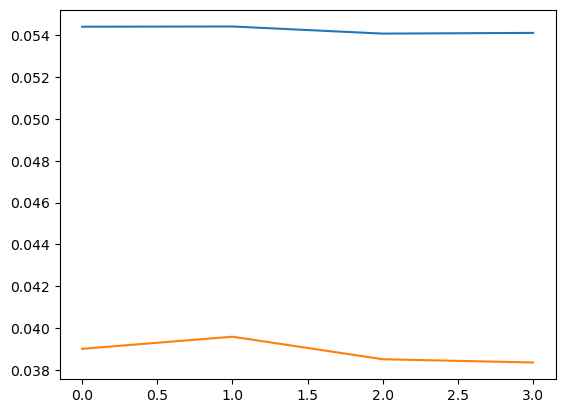

In [30]:
plt.plot(10* np.array(trainer.losses['decode-only']['eval']['diffusion']), label='diffusion')
plt.plot(trainer.losses['decode-only']['eval']['mse'])

In [49]:
self.training_configs['decode-onlya'].loss_weight_params

{'strategy': 'gradnorm',
 'lr': 0.025,
 'alpha': 0.5,
 'gradnorm_layer': -2,
 'T': 3.0,
 'update_interval': 20,
 'loss_weights': {'mse': 1.0, 'distribution': 0.0, 'diffusion': 10.0},
 'loss_schedule': {'mse': [0, 100],
  'distribution': [0, 100],
  'diffusion': [0, 100]}}

In [41]:
trainer.lw_history

defaultdict(list,
            {'mse-only': [[3.0, 0.0],
              [3.0, 0.0],
              [3.0, 0.0],
              [3.0, 0.0],
              [3.0, 0.0],
              [3.0, 0.0],
              [3.0, 0.0]],
             'decode-only': [[0.27272728085517883, 2.7272727489471436],
              [0.27272728085517883, 2.7272727489471436],
              [0.27618083357810974, 2.7238190174102783],
              [0.2794596552848816, 2.7205402851104736],
              [0.28268563747406006, 2.7173142433166504],
              [0.28592178225517273, 2.714078187942505],
              [0.2892145812511444, 2.710785150527954]],
             'encode-decode': [[0.27272728085517883, 2.7272727489471436],
              [0.27272728085517883, 2.7272727489471436],
              [0.27651503682136536, 2.723484992980957],
              [0.28023722767829895, 2.7197628021240234],
              [0.28398510813713074, 2.716014862060547],
              [0.28781643509864807, 2.712183713912964],
              [0.291

In [52]:
self.tconfigs = self.training_configs

In [62]:
self = trainer

master_dict = {'data_config': dataclasses.asdict(self.dconfig)}
master_dict['indices'] = [i.tolist() for i in self.indices]
for run_id in self.run_ids:
    master_dict[run_id] = {
        'model_config': dataclasses.asdict(self.mconfigs[run_id]),
        'training_config': dataclasses.asdict(self.tconfigs[run_id]),
        #'optimizer': self.optimizers[run_id].state_dict(),
        "losses": self.losses[run_id],
        "gradients": self.gradients[run_id],
        "L0": self.L0[run_id],
        
    }

In [64]:
with open(self.log_file_path, 'w') as f:
    json.dump(master_dict, f)

In [65]:
self.log_file_path

'/mnt/home/ssa2206/Climsim/experiments/DiffLossTesting/decode-only-test.json'

In [ ]:
def diffusion_loss(trainer, y_hat, run_id):
    #raise NotImplementedError("Diffusion loss not implemented")
    # TODO: y and yhat are of size (B, 128) and somehow need to convert into images for diffusion loss
    tconfig = trainer.training_configs[run_id]
    scheduler = trainer.schedulers[run_id]
    image_dim = 2 if "2" in tconfig.diffusion_strategy else 1
    y_image = trainer._make_image(y_hat, image_dim)
    def encode(sample):
        eps = torch.randn(sample.shape, device=sample.device) # BS x C x H x W
        xt = scheduler.add_noise(sample, eps, torch.LongTensor([tconfig.diffusion_loss_noise_level])) # noisy image
        return(xt)
    def decode(xt):
        og = xt.detach().clone()
        dists = []
        dist = torch.nn.MSELoss()
        with torch.no_grad():
            for t in range(tconfig.diffusion_loss_noise_level, 0, -tconfig.diffusion_loss_decoding_interval):
                eps_theta = trainer.unet(xt, t).sample
                xt = scheduler.step(eps_theta, t, xt).prev_sample
                dists.append(dist(og, xt).item())
        return(xt, dists)
    if "encode" in tconfig.diffusion_strategy:
        y_image = encode(y_image)
    y_image_denoised, dists = decode(y_image)
    return(tru.image_loss(tconfig)(y_image_denoised, y_image), dists)

In [ ]:
l, rdists = diffusion_loss(trainer, y, run_id)
l

tensor(0.0407, device='cuda:0')

In [ ]:
l, fdists = diffusion_loss(trainer, y_hat, run_id)
l

tensor(0.0420, device='cuda:0', grad_fn=<MseLossBackward0>)

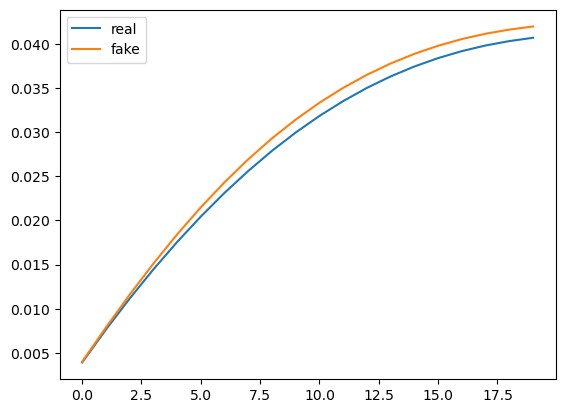

In [ ]:
plt.plot(rdists, label="real")
plt.plot(fdists, label="fake")
plt.legend()

In [ ]:
unet2d = tru.load_diffusion_model()

In [ ]:
run2d = evals.Run("diffusion_hp_search", "lr-explore", climsim_run = False, cid='best')
trainer = run2d.reconstruct_trainer(apply_checkpoints=True, apply_indices=False)

/srv/conda/envs/notebook/lib/python3.12/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
losses, self.loss_weights[run_id]

(tensor([1.5882e-02, 4.3194e+03, 4.1961e-02], device='cuda:0',
        grad_fn=<StackBackward0>),
 tensor([2.0310e-01, 1.6816e-04, 2.7967e+00], device='cuda:0',
        requires_grad=True))

In [ ]:
trainer.current_epoch = 7
trainer._return_loss_weights(tconfigs[3])

### Sanity Checking run_batch

In [ ]:
run = evals.Run()

In [ ]:
import copy

def params_of(model):
    return [p.detach().clone() for p in model.parameters()][-2]

In [ ]:
og_models = [copy.deepcopy(trainer.models[run_id]) for run_id in trainer.run_ids]

In [ ]:
import copy

for key in trainer.models:
    model = copy.deepcopy(og_models[0])
    tconfig = trainer.training_configs[key]
    trainer.models[key] = model
    print(params_of(trainer.models[key])[:2, :2], "\n")
    self.optimizers[key] = tru.create_optimizer(model, tconfig)


In [ ]:
x, y = next(iter(trainer.dataloaders['train']))

In [ ]:
import torch

initial_weights = {}
for key, model in trainer.models.items():
    param = list(model.parameters())[-2]
    initial_weights[key] = param.detach().clone()

batch_losses, params, after_params = _run_batch(trainer, x, y, phase='train', step=0)
new_weights = {}
for key, model in trainer.models.items():
    param = list(model.parameters())[-2]
    new_weights[key] = param.detach().clone()
    print(f"{key} updated:", not torch.allclose(param, initial_weights[key]))

In [ ]:
params[0] == after_params[0]

In [ ]:
after_params[0]

In [ ]:
self = trainer
for run_id, grads in self.gradients.items():
    print(run_id, trainer.training_configs[run_id].loss_weights)
    for loss_type, gradloss in grads.items():
        print(loss_type, gradloss['2.weight'])``
    print()

In [ ]:
[trainer.training_configs[run_id].num_gaussians for run_id in trainer.run_ids]

## VAE Training

In [ ]:
x = torch.tensor([7.0, 1, 5, 6, 2, 7, 2, 9]).to(device)
y = x * x
y.shape

model = torch.nn.Sequential(
    torch.nn.Linear(8, 16),
    torch.nn.ReLU(),
    torch.nn.Linear(16, 8),
).to(device)
optim = torch.optim.Adam(model.parameters())

losses = []
loss = 10
loss_fn = torch.nn.MSELoss()
step = 0
while loss > 0.1:
    pred = model(x)
    loss = loss_fn(pred, y)
    optim.zero_grad()
    loss.backward()
    optim.step()
    losses.append(loss.item())
    step += 1

In [ ]:
step, len(losses)

(866, 866)

# Training behavior  - Diffusion

# Training Behavior - Climsim

In [ ]:
def setup_climsim_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dataset_type = "climsim"
    dconfig = tru.my_dconfig("local-vzarr", data_vars, in_notebook, dataset_type, batch_size, use_tendencies=False)
    dconfig.train_test_split = [0.001, 0.001]
    #dconfig.shuffle_indices = Tr
    tconfigs, mconfigs = [], []

    learning_rates = [1e-4, 1e-4, 1e-4, 1e-4]
    mse_weights = [1.0, 1.0, 1.0, 1.0]
    distloss_weights = [0.0, 0.0, 0.01, 0.01] # [1.0, 1.0, 2.0, 5.0]
    diffloss_weights = [0.0, 10.0, 0.0, 10.0]
    target_variables_distloss = [68, 73, 82] # previously included 60 asw
    num_gaussians = [3, 2, 3, 2]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train', 'eval']
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.loss_weights = {'mse': mse_weights[i], 'distribution': distloss_weights[i], 'diffusion': diffloss_weights[i]}
        tconfig.loss_schedule = {'mse': 0, 'distribution': 5, 'diffusion': 5}
        tconfig.clip_gradients = True
        
        tconfig.distloss_var_inds = target_variables_distloss
        tconfig.num_gaussians = num_gaussians
        tconfig.diffusion_loss_noise_level = 20
        tconfig.distloss_var_sel = "uniform"

        tconfig.log_gradients = True
        tconfig.batch_checkpoint_interval = 50
        tconfigs.append(tconfig)
        
        mconfig = tru.ModelConfig(unet=tru.UNetParams(), scheduler=tru.SchedulerParams())
        mconfig.data_vars = data_vars
        if("climsim" in dataset_type):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)

In [ ]:
tconfigs, mconfigs, dconfig = setup_climsim_run(
    num_models, exp_id, run_id, data_vars='v1', batch_size=64
)

trainer = ClimsimTrainer(dconfig, mconfigs, tconfigs, 
                torch.nn.MSELoss(), base_dir, run_id, rank=0)

In [ ]:
AbstractTrainer = trainers.AbstractTrainer
class DiffusionTrainerTest(AbstractTrainer):
    def __init__(self, dataloaders, indices, mconfigs, tconfigs, base_dir, base_run_id, **kwargs):
        super().__init__(dataloaders, indices, mconfigs, tconfigs, base_dir, base_run_id)
        self.scheduler = tru.load_scheduler(mconfigs[0])
    
    def _run_batch(self, images, phase='train'):
        batch_losses = {}
        for run_id in self.run_ids:
            model, optimizer = self.models[run_id], self.optimizers[run_id]
            tconfig, lr_scheduler = self.training_configs[run_id], self.lr_schedulers[run_id]
            #noisy_images = self.scheduler.add_noise(images, noises, timesteps)
            #noisy_images = og_noisy # images + sigma * noises
            noise_pred = model(noisy_images, 5).sample
            loss = self.loss_fn(noise_pred, noises)
            if(phase == 'train'):
                optimizer.zero_grad()
                loss.backward()
                if(tconfig.clip_gradients and False):
                    total_grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                if(lr_scheduler is not None):
                    lr_scheduler.step()
            batch_losses[run_id] = loss.item()
        return(batch_losses)

    def _run_epoch(self, images, timesteps, phase='train'):
        for run_id in self.run_ids:
            self.models[run_id].train(phase=='train')
        with torch.set_grad_enabled(phase=='train'):
            if(self.distributed):
                self.dataloaders[phase].sampler.set_epoch(self.current_epoch)
            dl = self.dataloaders[phase]
            for step in range(len(dl)):
                batch_losses = self._run_batch(images, timesteps, phase)
                self.log_step(batch_losses, step, phase)
                del batch_losses

    def log_step(self, batch_losses, step, phase):
        
        if(step % self.bli == 0 or step+1 == len(self.dataloaders[phase])):
            for run_id in self.run_ids:
                self.losses.setdefault(run_id, defaultdict(list))[phase].append(batch_losses[run_id])

        if ((step+1) % self.ckpt_interval == 0 and phase == 'train'): 
            for run_id in self.run_ids:
                self._save_checkpoint(run_id)
    
    def _log_epoch_info(self, phase='train'):
        for run_id in self.run_ids:
            ind = self.batches_per_epoch[phase] // self.bli + 1
            epoch_losses = self.losses[run_id][phase][-ind:]
            avg_loss = sum(epoch_losses) / max(len(epoch_losses), 1)
            if self.current_epoch % 25 == 0:
                print(f"avg loss for epoch {self.current_epoch}, {run_id=}: {avg_loss}", flush=True)
            if(avg_loss < self.best_losses.setdefault(run_id, float('inf')) and phase=="train"):
                self.best_losses[run_id] = avg_loss


## Validating Errors

Including incidents of nan or anything else

In [ ]:
def score_function(x, mu, var, pi, clamp_val=10, epsilon=1e-7):
    mahal = (x[:,None] - mu) ** 2 / (2 * var)
    log_probs = torch.log(pi) - 0.5 * torch.log(var * 2 * torch.pi) - torch.clamp(mahal, max=clamp_val)
    qx = torch.exp(torch.logsumexp(log_probs, dim=1, keepdim=True)) + epsilon
        # Compute weighted derivative terms: pi * N(x|mu, var) * (x - mu) / var
    weighted_terms = torch.exp(log_probs) * torch.clamp((x[:,None] - mu) / var, max=clamp_val, min=-clamp_val)  # (N, K)
    # Sum over components and divide by q(x)
    score = -weighted_terms.sum(dim=1, keepdim=True) / qx    # (N, 1)
    return score.squeeze()

def u_q(x_1, x_2, mu, var, pi, h):
    assert len(x_1.shape) == 1 and len(x_2.shape) == 1, "expected 1d input"
    # x_1 and x_2 are samples from q(x), compared to knowledge distribution p(x) represented by mixture model. Thus, they are of shape (n_samples, d)
    sq1 = score_function(x_1, mu, var, pi)
    sq2 = score_function(x_2, mu, var, pi)

    print(sq1.isnan().any(), sq2.isnan().any())

    # Compute the final result based on bandwidth h
    if h == float('inf'):
        return torch.outer(sq1, sq2)
    
    diffs = x_1.unsqueeze(1) - x_2.unsqueeze(0)
    res = torch.outer(sq1, sq2)
    res += (sq1.reshape(-1,1) * diffs) / h**2
    res -= (sq2.reshape(1, -1) * diffs)/h**2
    res += (h**-2 - h**-4 * diffs ** 2)
    res = res * torch.exp(- (diffs ** 2) / (2 * h ** 2)) # kernel matrix
    return(res)

In [ ]:
trainer.bli = 1
trainer.train(1, log=True)

### Investigating Incidents

In [ ]:
from diffusionsim.evaluations import *

In [ ]:
incident  = trainer.nan_incidents['trial1b'][0]
print(incident.keys())
for name, p in incident['state_dict'].items():
    print(name, p.shape, torch.isnan(p).any())



In [ ]:
sample_model = tru.build_baseline_model(mconfigs[0]).to(device)
sample_model.eval()
sample_model.load_state_dict(incident['state_dict'])


In [ ]:
x, y = trainer.dataloaders['train'].dataset[335]
x, y = x.to(device), y.to(device)
y_hat = sample_model(x)
print(y_hat.shape, y.shape)
distribution_loss(trainer, y_hat, y, tconfigs[0], 0) # nan? 

In [ ]:
plt.hist(y[:, VAR_IND].detach().cpu().numpy(), bins=50, density=True, alpha=0.5, label='Data')
plt.show()

In [ ]:
x = torch.linspace(-2, 0, 1000)
density, = eval_density(x, GMM)
plt.plot(x, density)

In [ ]:
d = plot_gmm_distribution(y[:,VAR_IND].reshape(-1, 1), GMM)

In [ ]:
means_grads = {}
stds_grads = {}

for k in trainer.gradients['trial1d'].keys():
    means_grads[k] = []
    stds_grads[k] = []
    loss_grads = trainer.gradients['trial1d'][k]
    for name, stats in loss_grads.items():
        if(name == '2.weight'):
            for mean, std in stats:
                means_grads[k].append(mean)
                stds_grads[k].append(std)

# Trying to Improve Training

## Overfitting two samples

two_sample_ds = ClimsimImageDataset(Xarr[:2*384], Yarr[:2*384], mconfig, device=device, normalize=True)

In [70]:
from diffusionsim import nvidia_modulus
from diffusionsim.nvidia_modulus import *
from diffusionsim.models import *

In [4]:
source = "local-vzarr"
data_vars = 'v1'
in_notebook = True
shuffle_indices = False
dataset_type = "climsim_diffusion1d"
batch_size = 16
use_tendencies = False


In [5]:
dconfig = tru.my_dconfig(source, data_vars, in_notebook, shuffle_indices, dataset_type, batch_size, use_tendencies)
dconfig.train_test_split = [0.001]
dconfig.phases = ['train']


In [6]:
dataloaders, indices = data.load_dataloaders(dconfig, log=False)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [7]:
dl = dataloaders[0]
ds = dl.dataset
dutils = ds.dutils
y = next(iter(dl))

In [8]:
mconfig = tru.ModelConfig()
scheduler = tru.load_scheduler(mconfig)
scheduler.prediction_type = "v_prediction"
scheduler

DDPMScheduler {
  "_class_name": "DDPMScheduler",
  "_diffusers_version": "0.32.2",
  "beta_end": 0.02,
  "beta_schedule": "linear",
  "beta_start": 0.0001,
  "clip_sample": false,
  "clip_sample_range": 4.0,
  "dynamic_thresholding_ratio": 0.995,
  "num_train_timesteps": 100,
  "prediction_type": "epsilon",
  "rescale_betas_zero_snr": false,
  "sample_max_value": 1.0,
  "steps_offset": 0,
  "thresholding": false,
  "timestep_spacing": "leading",
  "trained_betas": null,
  "variance_type": "fixed_small"
}

In [9]:
pprint(mconfig)

ModelConfig(model_type='ddpm_diffusion',
            scheduler_type='ddpm',
            unet=UNetParams(sample_size=(16, 24),
                            in_channels=128,
                            out_channels=128,
                            extra_in_channels=0,
                            block_out_channels=(32, 64, 64, 128),
                            down_block_types=('DownBlock2D',
                                              'DownBlock2D',
                                              'AttnDownBlock2D',
                                              'DownBlock2D'),
                            up_block_types=('UpBlock2D',
                                            'AttnUpBlock2D',
                                            'UpBlock2D',
                                            'UpBlock2D'),
                            layers_per_block=1,
                            norm_num_groups=2,
                            act_fn='silu',
                            freq_shift=0.0,
    

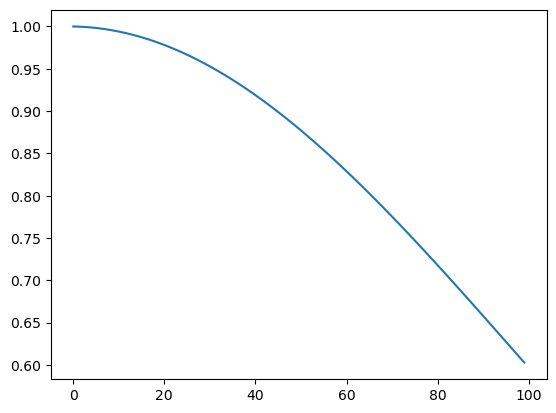

In [10]:
plt.plot(torch.sqrt(scheduler.alphas_cumprod.cpu()))

In [11]:
y.mean(), y.std()

(tensor(-0.0701), tensor(1.6746))

In [12]:
x0 = y[::3][::5][::7][:16].to(device)
eps = torch.randn(x0.shape, device=device)
timesteps = torch.full((x0.shape[0],), 70, device=device, dtype=torch.long)
xt = scheduler.add_noise(x0, eps, timesteps)

In [13]:
alpha_bar = scheduler.alphas_cumprod[timesteps].to(device)
print("alpha bar   ", alpha_bar[0])
while len(alpha_bar.shape) < len(x0.shape):
    alpha_bar = alpha_bar.unsqueeze(-1)
vt = torch.sqrt(alpha_bar) * eps - torch.sqrt(1 - alpha_bar) * x0
assert torch.allclose(vt, scheduler.get_velocity(x0, eps, timesteps))
vt.shape
torch.sqrt(alpha_bar[0,0]), torch.sqrt(1 - alpha_bar[0,0]), 

alpha bar    tensor(0.6011, device='cuda:0')


(tensor([0.7753], device='cuda:0'), tensor([0.6316], device='cuda:0'))

/mnt/home/ssa2206/Climsim/diffusion-climsim/diffusionsim/diffusionsim/evaluations.py:349: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


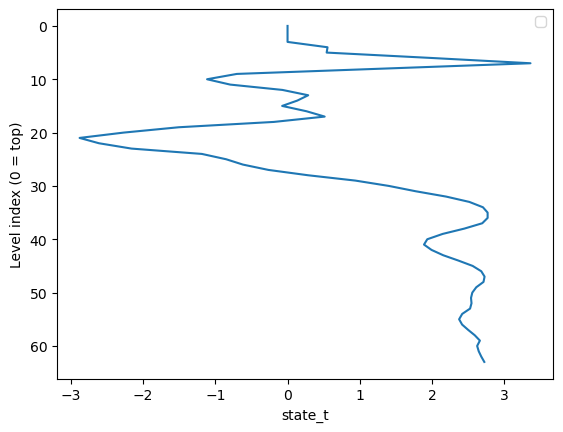

In [14]:
i = 4
evals.plot_profile(x0[i], var_index=0, ds=ds)

['vt', 'x0']


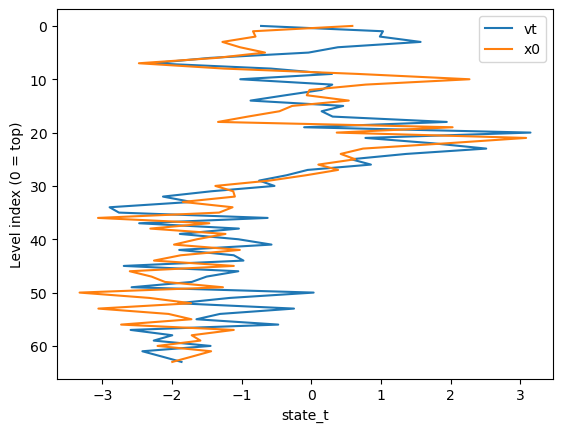

In [15]:
evals.plot_profile(torch.cat([vt[i:i+1], -xt[i:i+1]], axis=0), var_index=0, labels='vt x0'.split(), ds=ds)

In [16]:
target, target_name = vt, 'vt'

In [17]:
unet = mconfig.unet
unet.block_out_channels = (32, 32, 64) #if data_vars == "v1" else None
unet.down_block_types = ("DownResnetBlock1D", "AttnDownBlock1D", "DownBlock1D") #if data_vars=="v1" else None
unet.up_block_types = ("UpResnetBlock1D", "AttnUpBlock1D", "UpBlock1D") #if data_vars=="v1" else None
unet.in_channels = 10 if data_vars == "v1" else 14
unet.out_channels = 10 if data_vars == "v1" else 14

In [21]:
model.config.out_channels

10

In [47]:
model = tru.ModelLens(pass_config(ClimsimUNet1DModel, mconfig.unet).to(device))

skeet


In [89]:
from dataclasses import dataclass, asdict, field

In [95]:
@dataclass
class UNetParamsHF:
    in_channels: int = 128
    out_channels: int = 128
    extra_in_channels: int = 0
    block_out_channels: Tuple = field(default_factory=lambda: (32, 64, 64, 128))  # num output channel for each UNet block
    down_block_types: Tuple = field(default_factory=lambda: (
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "DownBlock2D",
    ))
    up_block_types: Tuple = field(default_factory=lambda: (
        "UpBlock2D",  # a regular ResNet upsampling block
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",
    ))
    layers_per_block: int = 1
    norm_num_groups: int = 2
    act_fn: str = "silu" # https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/activations.py#L27
    freq_shift: float = 0.0 # fourier freq shift
    use_timestep_embedding: bool = True
    time_embedding_dim: int = 32

@dataclass
class UNetParamsNV:
    num_vars_profile: int = 2
    num_vars_scalar: int = 4
    num_vars_profile_out: int = 2
    num_vars_scalar_out: int = 8
    diffusion_mode: bool = True
    model_channels: int = 64
    channel_mult: List[int] = field(default_factory=lambda: [1, 2, 2, 2])
    num_blocks: int = 3
    attn_resolutions: List[int] = field(default_factory=lambda: [16])
    conditioning_resolutions: Dict[int, List[str]] = field(default_factory=lambda: {
        64: ["timesteps"],
        32: ["timesteps"],
        16: ["timesteps"],
        8: ["timesteps"],
    })
    dropout: float = 0.0
    output_scale_type: str = 'scale-only'
    kernel_size: int = 3
    time_embedding_dim: int = 32

In [99]:
SchedulerParams = tru.SchedulerParams
@dataclass
class ModelConfig:
    model_type: str = "ddpm_diffusion"
    scheduler_type: str = 'ddpm'
    unet: UNetParamsNV | UNetParamsHF = field(default_factory=lambda: UNetParamsNV())
    scheduler: SchedulerParams = field(default_factory=lambda:SchedulerParams())
    scheduler_inference_steps: int = 100
    # VAE params
    num_channels: int = 128
    latent_dims: int = 16
    ae_hidden_dims: List[int] = field(default_factory=lambda: [64, 32, 16])
    disable_enc_logstd_bias: bool = True
    # Baseline Model Params
    bl_model_dir: str = "/mnt/home/ssa2206/Climsim/climsim-online/storage/shared_e3sm/saved_models/wrapper"
    bl_load_model_name: str = None
    bl_input_size: int = 124
    bl_output_size: int = 128
    bl_hidden_dims: List[int] = field(default_factory=lambda: [256, 256, 256]) 
    def __post_init__(self):
        if isinstance(self.unet, dict):
            if "hf" in self.model_type.lower():
                self.unet = UNetParamsHF(**self.unet)
            else:
                self.unet = UNetParamsNV(**self.unet)
        if isinstance(self.scheduler, dict):
            self.scheduler = SchedulerParams(**self.scheduler)  

In [100]:
mconfig = ModelConfig()

In [104]:
import inspect

In [107]:
inspect.signature(build_baseline_model).parameters

mappingproxy({'config': <Parameter "config">,
              'kwargs': <Parameter "**kwargs">})

In [103]:
pprint(mconfig.unet)

UNetParamsNV(num_vars_profile=2,
             num_vars_scalar=4,
             num_vars_profile_out=2,
             num_vars_scalar_out=8,
             diffusion_mode=True,
             model_channels=64,
             channel_mult=[1, 2, 2, 2],
             num_blocks=3,
             attn_resolutions=[16],
             conditioning_resolutions={8: ['timesteps'],
                                       16: ['timesteps'],
                                       32: ['timesteps'],
                                       64: ['timesteps']},
             dropout=0.0,
             output_scale_type='scale-only',
             kernel_size=3,
             time_embedding_dim=32)


In [21]:
#TODO : try zeuyan unet to see of lower loss floor
model = unet = self = tru.ModelLens(ClimsimUnet(
    num_vars_profile=len([v for v in dutils.input_vars if v in dutils.level_variables]),
    num_vars_scalar=len([v for v in dutils.input_vars if v in dutils.normal_variables]),
    num_vars_profile_out=len([v for v in dutils.target_vars if v in dutils.level_variables]),
    num_vars_scalar_out=len([v for v in dutils.target_vars if v in dutils.normal_variables]),
    diffusion_mode = True,
    model_channels= 64,
    kernel_size=3,
    channel_mult = [1, 8, 8, 8],
    attn_resolutions=[], conditioning_resolutions={64:[], 32:[], 16 : [], 8 : []},
    dropout=0.0, 
    output_scale_type='scale-only'
).to(device))

In [76]:
ClimsimUnet

diffusionsim.nvidia_modulus.ClimsimUnet

In [75]:
len(dutils.target_vars)

10

In [78]:
pprint(mconfig)

ModelConfig(model_type='ddpm_diffusion',
            scheduler_type='ddpm',
            unet=UNetParams(sample_size=(16, 24),
                            in_channels=10,
                            out_channels=10,
                            extra_in_channels=0,
                            block_out_channels=(32, 32, 64),
                            down_block_types=('DownResnetBlock1D',
                                              'AttnDownBlock1D',
                                              'DownBlock1D'),
                            up_block_types=('UpResnetBlock1D',
                                            'AttnUpBlock1D',
                                            'UpBlock1D'),
                            layers_per_block=1,
                            norm_num_groups=2,
                            act_fn='silu',
                            freq_shift=0.0,
                            use_timestep_embedding=True,
                            time_embedding_dim=32),
        

In [ ]:
import dataclasses

md = dataclasses.asdict(mconfig)

md['unet'].update({"diffusion_mode" : True})

{'model_type': 'ddpm_diffusion',
 'scheduler_type': 'ddpm',
 'unet': {'sample_size': (16, 24),
  'in_channels': 10,
  'out_channels': 10,
  'extra_in_channels': 0,
  'block_out_channels': (32, 32, 64),
  'down_block_types': ('DownResnetBlock1D', 'AttnDownBlock1D', 'DownBlock1D'),
  'up_block_types': ('UpResnetBlock1D', 'AttnUpBlock1D', 'UpBlock1D'),
  'layers_per_block': 1,
  'norm_num_groups': 2,
  'act_fn': 'silu',
  'freq_shift': 0.0,
  'use_timestep_embedding': True,
  'time_embedding_dim': 32,
  'diffusion_mode': True},
 'scheduler': {'num_train_timesteps': 100,
  'beta_schedule': 'linear',
  'clip_sample': False,
  'clip_sample_range': 4.0,
  'beta_end': 0.02,
  'prediction_type': 'epsilon'},
 'scheduler_inference_steps': 100,
 'num_channels': 128,
 'latent_dims': 16,
 'ae_hidden_dims': [64, 32, 16],
 'disable_enc_logstd_bias': True,
 'bl_model_dir': '/mnt/home/ssa2206/Climsim/climsim-online/storage/shared_e3sm/saved_models/wrapper',
 'bl_load_model_name': None,
 'bl_input_size':

In [81]:
isinstance(mconfig, dataclass)

TypeError: isinstance() arg 2 must be a type, a tuple of types, or a union

In [25]:
model.get_param(-1), model.param_names[-1]

(Parameter containing:
 tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0',
        requires_grad=True),
 'scale_output.weight')

In [48]:
list(model.named_parameters())[-3:]

[('mid_block.resnets.5.group_norm_2.weight',
  Parameter containing:
  tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0',
         requires_grad=True)),
 ('mid_block.resnets.5.group_norm_2.bias',
  Parameter containing:
  tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         device='cuda:0', requires_grad=True)),
 ('scale_output.weight',
  Parameter containing:
  tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0',
         requires_grad=True))]

In [69]:
mconfig

ModelConfig(model_type='ddpm_diffusion', scheduler_type='ddpm', unet=UNetParams(sample_size=(16, 24), in_channels=10, out_channels=10, extra_in_channels=0, block_out_channels=(32, 32, 64), down_block_types=('DownResnetBlock1D', 'AttnDownBlock1D', 'DownBlock1D'), up_block_types=('UpResnetBlock1D', 'AttnUpBlock1D', 'UpBlock1D'), layers_per_block=1, norm_num_groups=2, act_fn='silu', freq_shift=0.0, use_timestep_embedding=True, time_embedding_dim=32), scheduler=SchedulerParams(num_train_timesteps=100, beta_schedule='linear', clip_sample=False, clip_sample_range=4.0, beta_end=0.02, prediction_type='epsilon'), scheduler_inference_steps=100, num_channels=128, latent_dims=16, ae_hidden_dims=[64, 32, 16], disable_enc_logstd_bias=True, bl_model_dir='/mnt/home/ssa2206/Climsim/climsim-online/storage/shared_e3sm/saved_models/wrapper', bl_load_model_name=None, bl_input_size=124, bl_output_size=128, bl_hidden_dims=[256, 256, 256])

In [49]:
model

ClimsimUNet1DModel(
  (time_proj): GaussianFourierProjection()
  (time_mlp): TimestepEmbedding(
    (linear_1): Linear(in_features=32, out_features=128, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=128, out_features=32, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownResnetBlock1D(
      (resnets): ModuleList(
        (0): ResidualTemporalBlock1D(
          (conv_in): Conv1dBlock(
            (conv1d): Conv1d(10, 32, kernel_size=(5,), stride=(1,), padding=(2,))
            (group_norm): GroupNorm(8, 32, eps=1e-05, affine=True)
            (mish): Mish()
          )
          (conv_out): Conv1dBlock(
            (conv1d): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
            (group_norm): GroupNorm(8, 32, eps=1e-05, affine=True)
            (mish): Mish()
          )
          (time_emb_act): Mish()
          (time_emb): Linear()
          (residual_conv): Conv1d(10, 32, kernel_size=(1,), stride=(1,))
        )
        (1): ResidualTemporalB

In [ ]:
loss = 10
loss_fn = torch.nn.MSELoss()
#trainer = self = DiffusionTrainerTest(dataloaders, indices, mconfigs, tconfigs, base_dir, run_id)
optimizer = torch.optim.Adam([
    {"params" : [p for n, p in model.named_parameters() if 'scale_output' not in n], "lr" : 0.0001},
    {"params" : [model.scale_output.weight], "lr" : 1e-1, "weight_decay" : 0.0},
])
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.9)
losses, lrs = [], []
step = 0
while loss > 0.01 and step < 1000:
    pred = model(xt, timesteps).sample
    loss = loss_fn(pred, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    lr_scheduler.step()
    lrs.append(lr_scheduler.get_last_lr()[0])
    step += 1 
print("done at step", step, "loss", loss)

done!


In [55]:
model.scale_output.weight

Parameter containing:
tensor([ 2.6872,  1.3975,  1.0245,  1.5222,  1.1409, -0.4317,  1.1826,  0.9997,
         1.0920,  0.9296], device='cuda:0', requires_grad=True)

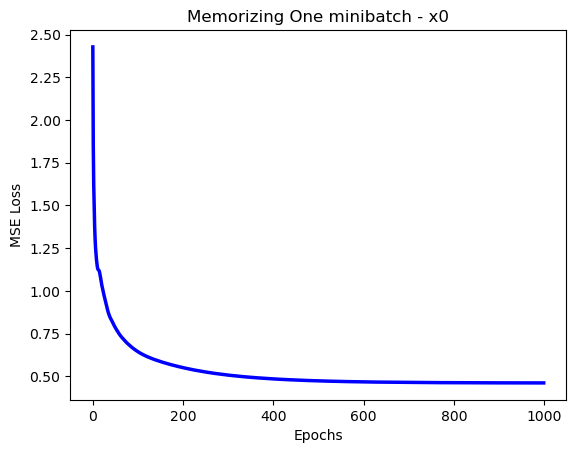

In [56]:
plt.plot(losses, color='blue', linewidth=2.50)
plt.title("Memorizing One minibatch - x0")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

In [58]:
pred = model(xt, timesteps)
pred = model(xt, timesteps).sample

In [59]:
loss = loss_fn(pred, target)
loss.backward()
loss

tensor(0.4610, device='cuda:0', grad_fn=<MseLossBackward0>)

In [60]:
model.get_param(-1), model.get_param(-1).grad

(Parameter containing:
 tensor([ 2.6872,  1.3975,  1.0245,  1.5222,  1.1409, -0.4317,  1.1826,  0.9997,
          1.0920,  0.9296], device='cuda:0', requires_grad=True),
 tensor([-0.0027, -0.0013, -0.0034, -0.0019, -0.0027,  0.0008, -0.0015, -0.0012,
         -0.0010, -0.0034], device='cuda:0'))

In [61]:
eps = 1e-8
num = (pred * target).sum(dim=(0,2))          # shape [C]
den = (pred * pred).sum(dim=(0,2)) + eps     # shape [C]
g_init = (num / den).detach()                # shape [C]
g_init

tensor([1.0078, 1.0038, 1.0155, 1.0031, 1.0136, 1.0059, 1.0087, 1.0050, 1.0059,
        1.0200], device='cuda:0')

In [62]:
num / den

tensor([1.0078, 1.0038, 1.0155, 1.0031, 1.0136, 1.0059, 1.0087, 1.0050, 1.0059,
        1.0200], device='cuda:0', grad_fn=<DivBackward0>)

In [63]:
def plot_profile(data, var_index=None, ax=None, title='', ds=None, **kwargs):
    if torch.is_tensor(data):
        data = data.detach().cpu().numpy()
    assert data.ndim < 4, "no more than 3d"
    if data.ndim == 3:
        assert var_index is not None, "need to specify variable"
        data = data[:, var_index, :]
    elif(data.ndim == 2 and 5 <= data.shape[0] <= 16):
        data = data[var_index]
    levels = np.arange(data.shape[-1])
    if ax is None:
        fig, ax = plt.subplots()
    if data.ndim == 1:
        print(data.shape)
        im = ax.plot(data, levels, **kwargs)
    else:
        if 'labels' in kwargs and len(kwargs['labels']) == len(data):
            labels = kwargs['labels']
            print(labels)
        for i, profile in enumerate(data): 
            im = ax.plot(profile, levels, label=labels[i])
    plt.legend()
    ax.invert_yaxis()
    ax.set_ylabel("Level index (0 = top)")
    ax.set_title(title)
    if var_index is not None: 
        ax.set_xlabel(ds.target_vars[var_index])
    return(im)

['pred', 'target']


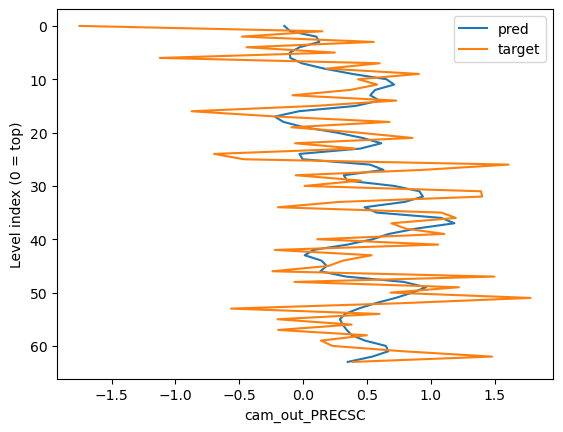

In [67]:
plot_profile(torch.cat([pred[0:1], target[0:1]], dim=0), var_index=4, ds=ds, labels='pred target'.split())

0 tensor(0.3454, device='cuda:0') tensor(2.6983, device='cuda:0')
1 tensor(0.3917, device='cuda:0') tensor(1.3919, device='cuda:0')
2 tensor(0.4863, device='cuda:0') tensor(1.0665, device='cuda:0')
3 tensor(0.4095, device='cuda:0') tensor(2.7556, device='cuda:0')
4 tensor(0.4860, device='cuda:0') tensor(1.0450, device='cuda:0')
5 tensor(0.5635, device='cuda:0') tensor(0.6623, device='cuda:0')
6 tensor(0.5097, device='cuda:0') tensor(1.0354, device='cuda:0')
7 tensor(0.4537, device='cuda:0') tensor(1.0563, device='cuda:0')
8 tensor(0.4561, device='cuda:0') tensor(0.9197, device='cuda:0')
9 tensor(0.5082, device='cuda:0') tensor(0.9069, device='cuda:0')


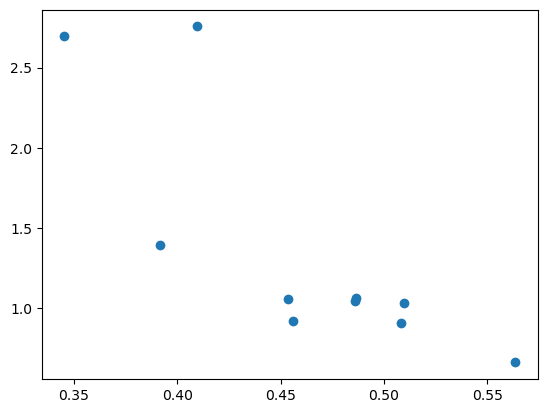

In [66]:
losses = []
variances = []
with torch.no_grad():
    for channel in range(x0.shape[1]):
        pc = pred[:,channel]
        tc = target[:,channel]
        print(channel, loss_fn(pc, tc), torch.var(tc))
        losses.append(loss_fn(pc, tc).item())
        variances.append(torch.var(tc).item())

plt.plot(losses, variances, 'o')


In [ ]:
gain = torch.ones(10, requires_grad=False)
gain[0] = 2
gain = nn.Parameter(gain).to(device)
gain_optim = torch.optim.Adam([gain], lr=0.001)
gain

In [ ]:
#fig, ax = plt.subplots(1, 1)
im1 = plot_profile(torch.cat([pred[i:i+1], target[i:i+1]/2], dim=0), 4, labels=f'prediction {target_name}'.split())
plt.title(f"{target_name} Prediction at T=20")
plt.show()

In [ ]:
losses = np.array(losses)

np.corrcoef(losses, var)

plt.plot(losses, var, 'o')

## Experimenting with Accelerators

In [ ]:
from diffusers import DDPMPipeline
from diffusers.utils import make_image_grid
from accelerate import Accelerator
from huggingface_hub import create_repo, upload_folder
from tqdm.auto import tqdm
from pathlib import Path

def evaluate(config, epoch, pipeline):
    # Sample some images from random noise (this is the backward diffusion process).
    # The default pipeline output type is `List[PIL.Image]`
    images = pipeline(
        batch_size=config.eval_batch_size,
        generator=torch.Generator(device=device).manual_seed(config.seed), # Use a separate torch generator to avoid rewinding the random state of the main training loop
    ).images

    # Make a grid out of the images
    image_grid = make_image_grid(images, rows=4, cols=4)

    # Save the images
    test_dir = os.path.join(config.output_dir, "samples")
    os.makedirs(test_dir, exist_ok=True)
    image_grid.save(f"{test_dir}/{epoch:04d}.png")

In [ ]:
def train_loop(config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler):
    # Initialize accelerator and tensorboard logging
    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        #log_with="tensorboard",
        project_dir=os.path.join(config.output_dir, "logs"),
    )
    if accelerator.is_main_process:
        if config.output_dir is not None:
            os.makedirs(config.output_dir, exist_ok=True)
        if config.push_to_hub:
            repo_id = create_repo(
                repo_id=config.hub_model_id or Path(config.output_dir).name, exist_ok=True
            ).repo_id
        accelerator.init_trackers("train_example")


    # Prepare everything
    # There is no specific order to remember, you just need to unpack the
    # objects in the same order you gave them to the prepare method.
    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    global_step = 0

    # Now you train the model
    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, clean_images in enumerate(train_dataloader):
            # Sample noise to add to the images
            noise = torch.randn(clean_images.shape, device=clean_images.device)
            bs = clean_images.shape[0]

            # Sample a random timestep for each image
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps, (bs,), device=clean_images.device,
                dtype=torch.int64
            )

            # Add noise to the clean images according to the noise magnitude at each timestep
            # (this is the forward diffusion process)
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(model):
                # Predict the noise residual
                noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
                loss = F.mse_loss(noise_pred, noise)
                accelerator.backward(loss)

                accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            progress_bar.update(1)
            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
            progress_bar.set_postfix(**logs)
            accelerator.log(logs, step=global_step)
            global_step += 1

        # After each epoch you optionally sample some demo images with evaluate() and save the model
        try:
            if accelerator.is_main_process:
                pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)
    
                if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
                    evaluate(config, epoch, pipeline)
    
                if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
                    if config.push_to_hub:
                        upload_folder(
                            repo_id=repo_id,
                            folder_path=config.output_dir,
                            commit_message=f"Epoch {epoch}",
                            ignore_patterns=["step_*", "epoch_*"],
                        )
                    else:
                        pipeline.save_pretrained(config.output_dir)
        except: 
            print("Ran into error with sampling and evaluating")
        
        return(model)

In [ ]:
from accelerate import notebook_launcher

args = (config, model, noise_scheduler, optimizer, dataloader, lr_scheduler)

model = notebook_launcher(train_loop, args, num_processes=1)

# Scratch Work

In [30]:
nvidia_modulus

<module 'diffusionsim.nvidia_modulus' from '/mnt/home/ssa2206/Climsim/diffusion-climsim/diffusionsim/diffusionsim/nvidia_modulus.py'>

In [ ]:
class ClimsimUNet1DModel(diffusers.models.ModelMixin, diffusers.configuration_utils.ConfigMixin):
    r"""
    A 1D UNet model that takes a noisy sample and a timestep and returns a sample shaped output.

    This model inherits from [`ModelMixin`]. Check the superclass documentation for it's generic methods implemented
    for all models (such as downloading or saving).

    Parameters:
        sample_size (`int`, *optional*): Default length of sample. Should be adaptable at runtime.
        in_channels (`int`, *optional*, defaults to 2): Number of channels in the input sample.
        out_channels (`int`, *optional*, defaults to 2): Number of channels in the output.
        extra_in_channels (`int`, *optional*, defaults to 0):
            Number of additional channels to be added to the input of the first down block. Useful for cases where the
            input data has more channels than what the model was initially designed for.
        time_embedding_type (`str`, *optional*, defaults to `"fourier"`): Type of time embedding to use.
        freq_shift (`float`, *optional*, defaults to 0.0): Frequency shift for Fourier time embedding.
        flip_sin_to_cos (`bool`, *optional*, defaults to `False`):
            Whether to flip sin to cos for Fourier time embedding.
        down_block_types (`Tuple[str]`, *optional*, defaults to `("DownBlock1DNoSkip", "DownBlock1D", "AttnDownBlock1D")`):
            Tuple of downsample block types.
        up_block_types (`Tuple[str]`, *optional*, defaults to `("AttnUpBlock1D", "UpBlock1D", "UpBlock1DNoSkip")`):
            Tuple of upsample block types.
        block_out_channels (`Tuple[int]`, *optional*, defaults to `(32, 32, 64)`):
            Tuple of block output channels.
        mid_block_type (`str`, *optional*, defaults to `"UNetMidBlock1D"`): Block type for middle of UNet.
        out_block_type (`str`, *optional*, defaults to `None`): Optional output processing block of UNet.
        act_fn (`str`, *optional*, defaults to `None`): Optional activation function in UNet blocks.
        norm_num_groups (`int`, *optional*, defaults to 8): The number of groups for normalization.
        layers_per_block (`int`, *optional*, defaults to 1): The number of layers per block.
        downsample_each_block (`int`, *optional*, defaults to `False`):
            Experimental feature for using a UNet without upsampling.
    """

    _skip_layerwise_casting_patterns = ["norm"]

    @diffusers.configuration_utils.register_to_config
    def __init__(
        self,
        sample_size: int = 65536,
        sample_rate: Optional[int] = None,
        in_channels: int = 2,
        out_channels: int = 2,
        extra_in_channels: int = 0,
        time_embedding_type: str = "fourier",
        time_embedding_dim: int = 0,
        flip_sin_to_cos: bool = True,
        use_timestep_embedding: bool = False,
        freq_shift: float = 0.0,
        down_block_types: Tuple[str] = ("DownBlock1DNoSkip", "DownBlock1D", "AttnDownBlock1D"),
        up_block_types: Tuple[str] = ("AttnUpBlock1D", "UpBlock1D", "UpBlock1DNoSkip"),
        mid_block_type: Tuple[str] = "UNetMidBlock1D",
        out_block_type: str = None,
        block_out_channels: Tuple[int] = (32, 32, 64),
        act_fn: str = None,
        norm_num_groups: int = 8,
        layers_per_block: int = 1,
        downsample_each_block: bool = False,
        output_scale_type: str = "scale-only",
    ):
        super().__init__()
        self.sample_size = sample_size

        # time
        if time_embedding_type == "fourier":
            time_embed_dim = time_embedding_dim or block_out_channels[0] * 2
            if time_embed_dim % 2 != 0:
                raise ValueError(f"`time_embed_dim` should be divisible by 2, but is {time_embed_dim}.")
            self.time_proj = GaussianFourierProjection(
                embedding_size=time_embed_dim // 2, set_W_to_weight=False, log=False, flip_sin_to_cos=flip_sin_to_cos
            )
            timestep_input_dim = time_embed_dim
        elif time_embedding_type == "positional":
            time_embed_dim = time_embedding_dim or block_out_channels[0]
            self.time_proj = Timesteps(
                time_embed_dim, flip_sin_to_cos=flip_sin_to_cos, downscale_freq_shift=freq_shift
            )
            timestep_input_dim = time_embed_dim
        else:
            raise ValueError(
                f"{time_embedding_type} does not exist. Please make sure to use one of `fourier` or `positional`."
            )

        if use_timestep_embedding:
            time_embed_dim = block_out_channels[0] * 4
            self.time_mlp = TimestepEmbedding(
                in_channels=timestep_input_dim,
                time_embed_dim=time_embed_dim,
                act_fn=act_fn,
                out_dim=block_out_channels[0],
            )

        self.down_blocks = nn.ModuleList([])
        self.mid_block = None
        self.up_blocks = nn.ModuleList([])
        self.out_block = None

        # down
        output_channel = in_channels
        for i, down_block_type in enumerate(down_block_types):
            input_channel = output_channel
            output_channel = block_out_channels[i]

            if i == 0:
                input_channel += extra_in_channels

            is_final_block = i == len(block_out_channels) - 1

            down_block = blocks_1d.get_down_block(
                down_block_type,
                num_layers=layers_per_block,
                in_channels=input_channel,
                out_channels=output_channel,
                temb_channels=timestep_input_dim,
                add_downsample=not is_final_block or downsample_each_block,
            )
            self.down_blocks.append(down_block)

        # mid
        self.mid_block = blocks_1d.get_mid_block(
            mid_block_type,
            in_channels=block_out_channels[-1],
            mid_channels=block_out_channels[-1],
            out_channels=block_out_channels[-1],
            temb_channels=timestep_input_dim,
            num_layers=layers_per_block,
            add_downsample=downsample_each_block,
        )

        # up
        reversed_block_out_channels = list(reversed(block_out_channels))
        output_channel = reversed_block_out_channels[0]
        if out_block_type is None:
            final_upsample_channels = out_channels
        else:
            final_upsample_channels = block_out_channels[0]

        for i, up_block_type in enumerate(up_block_types):
            prev_output_channel = output_channel
            output_channel = (
                reversed_block_out_channels[i + 1] if i < len(up_block_types) - 1 else final_upsample_channels
            )

            is_final_block = i == len(block_out_channels) - 1

            up_block = blocks_1d.get_up_block(
                up_block_type,
                num_layers=layers_per_block,
                in_channels=prev_output_channel,
                out_channels=output_channel,
                temb_channels=timestep_input_dim,
                add_upsample=not is_final_block,
            )
            self.up_blocks.append(up_block)
            prev_output_channel = output_channel

        # out
        num_groups_out = norm_num_groups if norm_num_groups is not None else min(block_out_channels[0] // 4, 32)
        self.out_block = blocks_1d.get_out_block(
            out_block_type=out_block_type,
            num_groups_out=num_groups_out,
            embed_dim=block_out_channels[0],
            out_channels=out_channels,
            act_fn=act_fn,
            fc_dim=block_out_channels[-1] // 4,
        )
        if output_scale_type == 'affine' or "bias" in output_scale_type:
            self.scale_output = blocks_1d.ChannelAffine(out_channels, cross_channel=False, bias=True)
        elif output_scale_type == 'scale-only' or output_scale_type == 'linear':
            self.scale_output = blocks_1d.ChannelAffine(out_channels, cross_channel=False, bias=False)
        elif 'cross' in output_scale_type or 'mixed' in output_scale_type:
            self.scale_output = blocks_1d.ChannelAffine(out_channels, cross_channel=True, bias=False)
        else:
            self.scale_output = None   

    def forward(
        self,
        sample: torch.Tensor,
        timestep: Union[torch.Tensor, float, int],
        return_dict: bool = True,
        debug=False,
    ) -> Union[UNet1DOutput, Tuple]:
        r"""
        The [`UNet1DModel`] forward method.

        Args:
            sample (`torch.Tensor`):
                The noisy input tensor with the following shape `(batch_size, num_channels, sample_size)`.
            timestep (`torch.Tensor` or `float` or `int`): The number of timesteps to denoise an input.
            return_dict (`bool`, *optional*, defaults to `True`):
                Whether or not to return a [`~models.unets.unet_1d.UNet1DOutput`] instead of a plain tuple.

        Returns:
            [`~models.unets.unet_1d.UNet1DOutput`] or `tuple`:
                If `return_dict` is True, an [`~models.unets.unet_1d.UNet1DOutput`] is returned, otherwise a `tuple` is
                returned where the first element is the sample tensor.
        """

        # 1. time
        timesteps = timestep
        if not torch.is_tensor(timesteps):
            timesteps = torch.tensor([timesteps], dtype=torch.long, device=sample.device)
        elif torch.is_tensor(timesteps) and len(timesteps.shape) == 0:
            timesteps = timesteps[None].to(sample.device)

        timestep_embed = self.time_proj(timesteps)
        if self.config.use_timestep_embedding:
            timestep_embed = self.time_mlp(timestep_embed.to(sample.dtype))
        timestep_embed = timestep_embed.broadcast_to((sample.shape[:1] + timestep_embed.shape[1:]))
        if debug:
            print(sample.shape, timestep_embed.shape)
        # 2. down
        down_block_res_samples = ()
        for downsample_block in self.down_blocks:
            sample, res_samples = downsample_block(hidden_states=sample, temb=timestep_embed)
            down_block_res_samples += res_samples

        # 3. mid
        if self.mid_block:
            sample = self.mid_block(sample, timestep_embed)

        # 4. up
        for i, upsample_block in enumerate(self.up_blocks):
            res_samples = down_block_res_samples[-1:]
            down_block_res_samples = down_block_res_samples[:-1]
            sample = upsample_block(sample, res_hidden_states_tuple=res_samples, temb=timestep_embed)

        # 5. post-process
        if self.out_block:
            sample = self.out_block(sample, timestep_embed)
        
        if self.scale_output:
            sample = self.scale_output(sample)

        if not return_dict:
            return (sample,)

        return UNet1DOutput(sample=sample)